Train Shape: (207146, 84)
Test Shape: (136743, 84)
Label
Normal        68423
DoS           52471
DDoS          48413
Probe         36372
BFA            1110
Web-Attack      192
BOTNET          164
Name: count, dtype: int64
After PCA: (207145, 15)
Epoch 1/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - loss: 0.0432 - val_loss: 0.0065
Epoch 2/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0021 - val_loss: 0.0061
Epoch 3/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0018 - val_loss: 0.0064
Epoch 4/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0017 - val_loss: 0.0065
Epoch 5/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0017 - val_loss: 0.0067
6474/6474 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1975/1975 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
GRU Feature Shape: (207145, 12)

FINAL RESULTS

Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     295.0
           3       0.00      0.00      0.00    1145.0
       

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\s

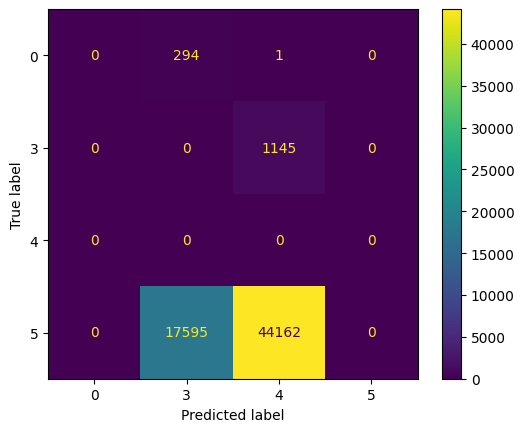

Cross-validation Accuracy: 0.992063530377272


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping


# =================================
# 1. LOAD DATA
# =================================

normal = pd.read_csv("Normal_data.csv")
meta = pd.read_csv("metasploitable-2.csv")
ovs = pd.read_csv("OVS.csv")

# Train on Normal + OVS
train_df = pd.concat([normal, ovs], axis=0)

# Test on unseen dataset
test_df = meta.copy()

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


# =================================
# 2. CLEAN
# =================================

train_df.drop_duplicates(inplace=True)
train_df.dropna(inplace=True)

test_df.drop_duplicates(inplace=True)
test_df.dropna(inplace=True)


# =================================
# 3. REMOVE TINY CLASSES
# =================================

counts = train_df["Label"].value_counts()
valid_classes = counts[counts > 50].index

train_df = train_df[train_df["Label"].isin(valid_classes)]
test_df = test_df[test_df["Label"].isin(valid_classes)]

print(train_df["Label"].value_counts())


# =================================
# 4. ENCODE
# =================================

le = LabelEncoder()

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        le.fit(pd.concat([train_df[col], test_df[col]]))
        train_df[col] = le.transform(train_df[col])
        test_df[col] = le.transform(test_df[col])


# =================================
# 5. FEATURES / LABEL
# =================================

X_train = train_df.drop("Label", axis=1)
y_train = train_df["Label"]

X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]


# =================================
# 6. SCALING
# =================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =================================
# 7. PCA
# =================================

pca = PCA(n_components=15)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("After PCA:", X_train_pca.shape)


# =================================
# ⭐ 8. GRU AUTOENCODER (FIXED)
# =================================

# reshape -> (samples, timesteps, features)
X_train_r = X_train_pca.reshape(-1, 1, 15)
X_test_r = X_test_pca.reshape(-1, 1, 15)

input_layer = Input(shape=(1, 15))

# Encoder
x = GRU(32, return_sequences=False)(input_layer)
encoded = Dense(12, activation='relu')(x)   # bottleneck features

# Decoder (must match 15!)
decoded = Dense(15, activation='linear')(encoded)

gru_autoencoder = Model(input_layer, decoded)

gru_autoencoder.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

gru_autoencoder.fit(
    X_train_r,
    X_train_pca,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


# =================================
# ⭐ 9. EXTRACT GRU FEATURES
# =================================

encoder_model = Model(inputs=input_layer, outputs=encoded)

X_train_gru = encoder_model.predict(X_train_r)
X_test_gru = encoder_model.predict(X_test_r)

print("GRU Feature Shape:", X_train_gru.shape)


# =================================
# ⭐ 10. XGBOOST
# =================================

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',   # faster
    random_state=42
)

xgb.fit(X_train_gru, y_train)

y_pred = xgb.predict(X_test_gru)


# =================================
# 11. RESULTS
# =================================

print("\nFINAL RESULTS\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# =================================
# 12. CONFUSION MATRIX
# =================================

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


# =================================
# 13. CROSS VALIDATION
# =================================

scores = cross_val_score(xgb, X_train_gru, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())


Cross-validation Accuracy: 0.9785850491201815

CROSS-VALIDATION METRICS

Precision: 0.9803784613684616
Recall: 0.9785802215839147
F1 Score: 0.9786709912246022


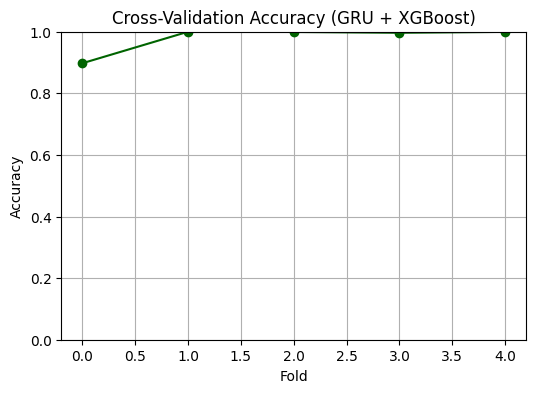

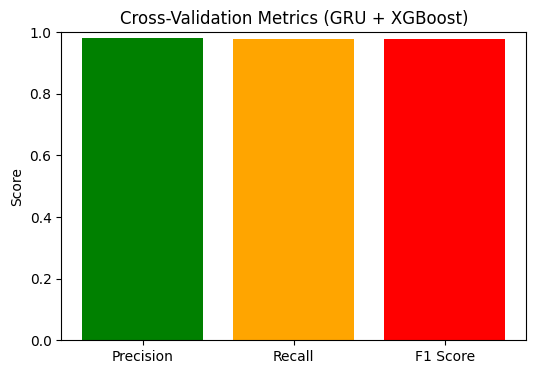

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

# ==============================
# PIPELINE (NO DATA LEAKAGE)
# ==============================
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=15)),
    ('xgb', XGBClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42,
        eval_metric='mlogloss'
    ))
])

# ==============================
# CROSS VALIDATION ACCURACY
# ==============================
scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())

# ==============================
# CROSS VALIDATION PREDICTIONS
# ==============================
y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

# ==============================
# METRICS
# ==============================
precision = precision_score(y_train, y_cv_pred, average='weighted')
recall = recall_score(y_train, y_cv_pred, average='weighted')
f1 = f1_score(y_train, y_cv_pred, average='weighted')

print("\nCROSS-VALIDATION METRICS\n")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==============================
# GRAPH 1: CV ACCURACY PER FOLD
# ==============================
plt.figure(figsize=(6,4))
plt.plot(scores, marker='o', color='darkgreen')
plt.title("Cross-Validation Accuracy (GRU + XGBoost)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.show()

# ==============================
# GRAPH 2: METRICS BAR GRAPH
# ==============================
metrics = [precision, recall, f1]
labels = ["Precision", "Recall", "F1 Score"]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics, color=['green','orange','red'])
plt.ylim(0,1)
plt.title("Cross-Validation Metrics (GRU + XGBoost)")
plt.ylabel("Score")
plt.show()